Домашнее задание: Прогнозирование зарплаты разработчика на основе данных опроса Stack Overflow
Цель работы: Применить нейросети для решения реальной задачи — предсказания зарплаты (или её аналога, например, ConvertedCompYearly) на основе ответов разработчиков на ежегодный опрос. Вы научитесь обрабатывать сложные смешанные данные (числовые, категориальные, множественного выбора), строить нейросетевые модели и оценивать их качество.

Источник данных: Stack Overflow Annual Developer Survey. Используйте данные последнего доступного года (например, 2024). Файл с результатами обычно доступен для скачивания в формате CSV.

# Блок 0: Постановка задачи
В этом задании вам предстоит построить нейросеть, которая по ответам респондента (его профессиональный опыт, используемые технологии, образование, страна проживания и т.д.) будет предсказывать его годовую зарплату. Это задача регрессии.

Целевая переменная: ConvertedCompYearly (годовая зарплата в долларах США).

Основные шаги:

Загрузить и изучить данные.

Провести предобработку: отбор признаков, обработка пропусков, кодирование.

Построить и обучить нейросеть в PyTorch.

Оценить качество модели.

# Блок 1: Загрузка данных

Перейдите на сайт Stack Overflow Developer Survey. Найдите раздел с данными последнего опроса (например, «Download the Data»). Скачайте файл с результатами (обычно это архив .zip с файлом .csv). Распакуйте архив и загрузите данные в pandas.

Ваша задача: Написать код для загрузки данных. Укажите правильный путь к файлу.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau, StepLR

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report
import warnings

warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('data/survey_results_public.csv')

In [3]:
data.describe()

,ResponseId,WorkExp,YearsCode,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,...,SO_Actions_3,SO_Actions_4,SO_Actions_5,SO_Actions_6,SO_Actions_9,SO_Actions_7,SO_Actions_10,SO_Actions_15,ConvertedCompYearly,JobSat
count,49191.000000,42893.000000,43042.000000,35975.000000,35975.000000,35975.000000,35975.000000,35975.000000,35975.000000,35975.000000,...,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,2.394700e+04,26670.000000
mean,24596.000000,13.367403,16.570861,7.867352,4.104211,4.110271,5.678193,4.119388,5.225990,6.477387,...,5.718355,4.561767,4.790861,5.199657,5.676314,4.984653,7.099505,10.079284,1.017615e+05,7.201950
std,14200.362883,10.800117,11.787610,2.397432,2.275821,2.329536,2.398084,2.437945,2.801045,2.331468,...,2.628016,3.070548,2.643177,2.563562,2.310659,2.490095,2.469394,1.940928,4.617569e+05,1.997245
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00,0.000000
25%,12298.500000,5.000000,8.000000,7.000000,2.000000,2.000000,4.000000,2.000000,3.000000,5.000000,...,3.000000,1.000000,3.000000,3.000000,4.000000,3.000000,6.000000,10.000000,3.817100e+04,6.000000
50%,24596.000000,10.000000,14.000000,9.000000,4.000000,4.000000,6.000000,4.000000,5.000000,7.000000,...,6.000000,4.000000,5.000000,5.000000,6.000000,5.000000,8.000000,10.000000,7.532000e+04,8.000000
75%,36893.500000,20.000000,24.000000,9.000000,6.000000,6.000000,8.000000,6.000000,8.000000,8.000000,...,8.000000,7.000000,7.000000,7.000000,7.000000,7.000000,9.000000,10.000000,1.205960e+05,8.000000
max,49191.000000,100.000000,100.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,...,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,5.000000e+07,10.000000


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Columns: 172 entries, ResponseId to JobSat
dtypes: float64(52), int64(1), str(119)
memory usage: 64.6 MB


In [5]:
data.head().T

,0,1,2,3,4
ResponseId,1,2,3,4,5
MainBranch,I am a developer by profession,I am a developer by profession,I am a developer by profession,I am a developer by profession,I am a developer by profession
Age,25-34 years old,25-34 years old,35-44 years old,35-44 years old,35-44 years old
EdLevel,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Associate degree (A.A., A.S., etc.)","Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Master’s degree (M.A., M.S., M.Eng., MBA, etc.)"
Employment,Employed,Employed,"Independent contractor, freelancer, or self-em...",Employed,"Independent contractor, freelancer, or self-em..."
...,...,...,...,...,...
AIAgentExtWrite,NaN,NaN,NaN,NaN,NaN
AIHuman,When I don’t trust AI’s answers,When I don’t trust AI’s answers;When I want to...,When I don’t trust AI’s answers;When I want to...,When I don’t trust AI’s answers;When I want to...,When I don’t trust AI’s answers
AIOpen,"Troubleshooting, profiling, debugging",All skills. AI is a flop.,"Understand how things actually work, problem s...",NaN,"critical thinking, the skill to define the tas..."
ConvertedCompYearly,61256.0,104413.0,53061.0,36197.0,60000.0


In [6]:
data.shape

(49191, 172)

In [7]:
data.columns.tolist()

['ResponseId',
 'MainBranch',
 'Age',
 'EdLevel',
 'Employment',
 'EmploymentAddl',
 'WorkExp',
 'LearnCodeChoose',
 'LearnCode',
 'LearnCodeAI',
 'AILearnHow',
 'YearsCode',
 'DevType',
 'OrgSize',
 'ICorPM',
 'RemoteWork',
 'PurchaseInfluence',
 'TechEndorseIntro',
 'TechEndorse_1',
 'TechEndorse_2',
 'TechEndorse_3',
 'TechEndorse_4',
 'TechEndorse_5',
 'TechEndorse_6',
 'TechEndorse_7',
 'TechEndorse_8',
 'TechEndorse_9',
 'TechEndorse_13',
 'TechEndorse_13_TEXT',
 'TechOppose_1',
 'TechOppose_2',
 'TechOppose_3',
 'TechOppose_5',
 'TechOppose_7',
 'TechOppose_9',
 'TechOppose_11',
 'TechOppose_13',
 'TechOppose_16',
 'TechOppose_15',
 'TechOppose_15_TEXT',
 'Industry',
 'JobSatPoints_1',
 'JobSatPoints_2',
 'JobSatPoints_3',
 'JobSatPoints_4',
 'JobSatPoints_5',
 'JobSatPoints_6',
 'JobSatPoints_7',
 'JobSatPoints_8',
 'JobSatPoints_9',
 'JobSatPoints_10',
 'JobSatPoints_11',
 'JobSatPoints_13',
 'JobSatPoints_14',
 'JobSatPoints_15',
 'JobSatPoints_16',
 'JobSatPoints_15_TEXT',
 

# Блок 3: Предобработка данных
Данные опроса содержат множество столбцов разного типа. Для построения модели мы выберем ограниченный набор признаков. Вам нужно обработать пропуски, закодировать категориальные переменные и подготовить данные для нейросети.

In [8]:
missing = data.isnull().sum()
missing.sort_values(ascending=False)

AIAgentObsWrite      48927
SOTagsWant Entry     48761
SOTagsHaveEntry      48733
AIModelsWantEntry    48716
AIAgentOrchWrite     48713
                     ...  
EdLevel               1042
Employment             852
ResponseId               0
MainBranch               0
Age                      0
Length: 172, dtype: int64

In [9]:
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns
print(numeric_cols)
print(f'{len(numeric_cols)} - числовые признаки')

Index(['ResponseId', 'WorkExp', 'YearsCode', 'TechEndorse_1', 'TechEndorse_2',
       'TechEndorse_3', 'TechEndorse_4', 'TechEndorse_5', 'TechEndorse_6',
       'TechEndorse_7', 'TechEndorse_8', 'TechEndorse_9', 'TechEndorse_13',
       'TechOppose_1', 'TechOppose_2', 'TechOppose_3', 'TechOppose_5',
       'TechOppose_7', 'TechOppose_9', 'TechOppose_11', 'TechOppose_13',
       'TechOppose_16', 'TechOppose_15', 'JobSatPoints_1', 'JobSatPoints_2',
       'JobSatPoints_3', 'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6',
       'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10',
       'JobSatPoints_11', 'JobSatPoints_13', 'JobSatPoints_14',
       'JobSatPoints_15', 'JobSatPoints_16', 'ToolCountWork',
       'ToolCountPersonal', 'CompTotal', 'SO_Actions_1', 'SO_Actions_16',
       'SO_Actions_3', 'SO_Actions_4', 'SO_Actions_5', 'SO_Actions_6',
       'SO_Actions_9', 'SO_Actions_7', 'SO_Actions_10', 'SO_Actions_15',
       'ConvertedCompYearly', 'JobSat'],
     

In [10]:
category_cols = data.select_dtypes(include=['object']).columns
print(category_cols)
print(f'{len(category_cols)} - категориальные признаки')

Index(['MainBranch', 'Age', 'EdLevel', 'Employment', 'EmploymentAddl',
       'LearnCodeChoose', 'LearnCode', 'LearnCodeAI', 'AILearnHow', 'DevType',
       ...
       'AIAgentKnowledge', 'AIAgentKnowWrite', 'AIAgentOrchestration',
       'AIAgentOrchWrite', 'AIAgentObserveSecure', 'AIAgentObsWrite',
       'AIAgentExternal', 'AIAgentExtWrite', 'AIHuman', 'AIOpen'],
      dtype='str', length=119)
119 - категориальные признаки


In [11]:
data = data.drop_duplicates()

In [12]:
data = data[data['ConvertedCompYearly'].notna()].copy()

In [13]:
# Выбор подходящих признаков для обучения модели + определение таргета
target = 'ConvertedCompYearly'
features = [
    'MainBranch',
    'Age',
    'EdLevel',
    'Employment',
    'WorkExp',
    'YearsCode',
    'DevType',
    'OrgSize',
    'Country',
]
# Создание новой таблицы
data_clean = data[features + [target]].copy()

In [14]:
# обработка пустых признаков
data_clean = data_clean[data_clean['Age'] != 'Prefer not to say']
data_clean = data_clean[data_clean['Employment'] != 'I prefer not to say']
data_clean = data_clean[data_clean['OrgSize'] != 'I don’t know']
data_clean = data_clean[data_clean['EdLevel'] != 'Other (please specify):']

In [15]:
# обработка MainBranch
strings_professional = [
    'I am a developer by profession',
    'I am not primarily a developer, but I write code sometimes as part of my work/studies',
    'I used to be a developer by profession, but no longer am'
]
data_clean['is_professional'] = data_clean['MainBranch'].isin(strings_professional).astype(int)
data_clean['is_professional'].value_counts()
data_clean.drop('MainBranch', axis=1, inplace=True)

In [16]:
# обработка Employed
strings_employed = [
    'Employed',
    'Independent contractor, freelancer, or self-employed',
]
data_clean['is_employed'] = data_clean['Employment'].isin(strings_employed).astype(int)
data_clean.drop('Employment', axis=1, inplace=True)

In [17]:
data_clean['Country'].value_counts()

Country
United States of America                                5107
Germany                                                 2072
United Kingdom of Great Britain and Northern Ireland    1452
India                                                   1063
France                                                  1006
                                                        ... 
Djibouti                                                   1
Turkmenistan                                               1
Burundi                                                    1
Belize                                                     1
Guinea                                                     1
Name: count, Length: 163, dtype: int64

In [18]:
# обработка Country
country_counts = data_clean['Country'].value_counts()
top_countries = country_counts.head(20).index.tolist()
data_clean['Country'] = data_clean['Country'].apply(
    lambda x: x if x in top_countries else 'Other'
)

In [19]:
q_low = data_clean['ConvertedCompYearly'].quantile(0.01)
q_hi  = data_clean['ConvertedCompYearly'].quantile(0.99)

data_clean = data_clean[(data_clean['ConvertedCompYearly'] > q_low) &
                        (data_clean['ConvertedCompYearly'] < q_hi)]
y = data_clean['ConvertedCompYearly']
data_clean  = data_clean.drop('ConvertedCompYearly', axis=1)

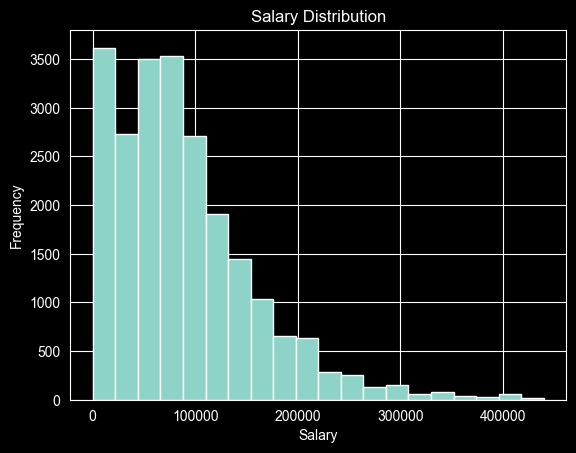

In [20]:
plt.figure()
plt.hist(y, bins=20)
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.title('Salary Distribution')
plt.show()

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    data_clean, y, test_size=0.2, random_state=42
)

In [22]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [23]:
# обработка пропусков у числовых признаков
median_WorkExp = X_train['WorkExp'].median()
median_YearsCode = X_train['YearsCode'].median()

X_train['WorkExp'] = X_train['WorkExp'].fillna(median_WorkExp)
X_test['WorkExp'] = X_test['WorkExp'].fillna(median_WorkExp)
X_train['YearsCode'] = X_train['YearsCode'].fillna(median_YearsCode)
X_test['YearsCode'] = X_test['YearsCode'].fillna(median_YearsCode)

# обработка пропусков у категориальных признаков
categorical_features = ['Age','EdLevel','DevType','OrgSize','Country']

for col in categorical_features:
    X_train[col] = X_train[col].replace(['', 'NA', 'None', 'NaN', 'null', ' '], np.nan)
    X_test[col] = X_test[col].replace(['', 'NA', 'None', 'NaN', 'null', ' '], np.nan)

    mode_val = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode_val)
    X_test[col] = X_test[col].fillna(mode_val)

# Осмотр категориальных признаков
for col in categorical_features:
    print(X_train[col].value_counts())
    print(X_train[col].isnull().sum())
    print(X_test[col].isnull().sum())
    print('-'*100)

Age
25-34 years old      6588
35-44 years old      5821
45-54 years old      2591
18-24 years old      1961
55-64 years old      1092
65 years or older     249
Name: count, dtype: int64
0
0
----------------------------------------------------------------------------------------------------
EdLevel
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          8040
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       5325
Some college/university study without earning a degree                                2235
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                        1050
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)     930
Associate degree (A.A., A.S., etc.)                                                    636
Primary/elementary school                                                               86
Name: count, dtype: int64
0
0
----------------------------------

In [24]:
# Кодировка Age
age_order = [
    '18-24 years old',
    '25-34 years old',
    '35-44 years old',
    '45-54 years old',
    '55-64 years old',
    '65 years or older'
]

ord_enc = OrdinalEncoder(categories=[age_order])
X_train['Age'] = ord_enc.fit_transform(X_train[['Age']])
X_test['Age'] = ord_enc.transform(X_test[['Age']])

In [25]:
# Кодировка EdLevel
education_order = [
    'Primary/elementary school',
    'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)',
    'Some college/university study without earning a degree',
    'Associate degree (A.A., A.S., etc.)',
    'Bachelor’s degree (B.A., B.S., B.Eng., etc.)',
    'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)',
    'Professional degree (JD, MD, Ph.D, Ed.D, etc.)'
]

ed_enc = OrdinalEncoder(categories=[education_order])
X_train['EdLevel'] = ed_enc.fit_transform(X_train[['EdLevel']])
X_test['EdLevel'] = ed_enc.transform(X_test[['EdLevel']])

In [26]:
X_train['DevType'].value_counts()

DevType
Developer, full-stack                            5747
Developer, back-end                              3033
Architect, software or solutions                 1224
Developer, desktop or enterprise applications     899
Developer, front-end                              837
Developer, embedded applications or devices       606
Other (please specify):                           589
Developer, mobile                                 587
Engineering manager                               542
DevOps engineer or professional                   539
Academic researcher                               411
Data engineer                                     392
Student                                           288
AI/ML engineer                                    272
Data scientist                                    260
Senior executive (C-suite, VP, etc.)              243
Cloud infrastructure engineer                     203
System administrator                              177
Developer, game or g

In [27]:
# Обработка 'DevType'
def group_roles(role):
    if pd.isna(role):
        return 'Other'
    role_lower = role.lower()
    if any(keyword in role_lower for keyword in ['data', 'ai', 'ml', 'scientist', 'analyst']):
        return 'Data & AI'
    if any(keyword in role_lower for keyword in ['architect', 'manager', 'executive', 'founder', 'lead']):
        return 'Architecture & Management'
    if any(keyword in role_lower for keyword in ['devops', 'cloud', 'infrastructure', 'administrator', 'admin', 'support']):
        return 'Infrastructure & DevOps'
    if any(keyword in role_lower for keyword in ['security', 'infosec', 'cyber']):
        return 'Security'
    if any(keyword in role_lower for keyword in ['ux', 'ui', 'design']):
        return 'Design'
    if any(keyword in role_lower for keyword in ['research', 'student']):
        return 'Research & Education'
    if 'developer' in role_lower or 'engineer' in role_lower:
        return 'Software Development'
    return 'Other'

X_train['DevType'] = X_train['DevType'].apply(group_roles)
X_test['DevType'] = X_test['DevType'].apply(group_roles)


In [28]:
X_train['DevType'].value_counts()

DevType
Software Development         12015
Architecture & Management     2357
Data & AI                     1487
Infrastructure & DevOps        919
Research & Education           699
Other                          640
Security                       151
Design                          34
Name: count, dtype: int64

In [29]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded_train = ohe.fit_transform(X_train[['DevType']])
encoded_test = ohe.transform(X_test[['DevType']])

feature_names = ohe.get_feature_names_out(['DevType'])

train_devtype_df = pd.DataFrame(encoded_train, columns=feature_names, index=X_train.index)
test_devtype_df = pd.DataFrame(encoded_test, columns=feature_names, index=X_test.index)

X_train = pd.concat([X_train.drop('DevType', axis=1), train_devtype_df], axis=1)
X_test = pd.concat([X_test.drop('DevType', axis=1), test_devtype_df], axis=1)

In [30]:
X_train['OrgSize'].value_counts()

OrgSize
20 to 99 employees                                    5406
100 to 499 employees                                  3130
Less than 20 employees                                2624
10,000 or more employees                              2420
1,000 to 4,999 employees                              2175
500 to 999 employees                                  1209
5,000 to 9,999 employees                               801
Just me - I am a freelancer, sole proprietor, etc.     537
Name: count, dtype: int64

In [31]:
import re
def group_org_size(company_size):
    if 'Just me' in company_size:
        return 'Freelancer'
    clean_str = str(company_size).replace(',', '')
    match = re.search(r'\d+', clean_str)
    if match:
        num = int(match.group())
        if num < 20:
            return 'Micro (1-19)'
        elif num < 100:
            return 'Small (20-99)'
        elif num < 500:
            return 'Medium-Small (100-499)'
        elif num < 1000:
            return 'Medium (500-999)'
        elif num < 5000:
            return 'Large (1000-4999)'
        else:
            return 'Enterprise (5000+)'
    return 'Unknown'

X_train['OrgSize'] = X_train['OrgSize'].apply(group_org_size)
X_test['OrgSize'] = X_test['OrgSize'].apply(group_org_size)

In [32]:
ohe_org_size = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded_train_OrgSize = ohe_org_size.fit_transform(X_train[['OrgSize']])
encoded_test_OrgSize = ohe_org_size.transform(X_test[['OrgSize']])

feature_names = ohe_org_size.get_feature_names_out(['OrgSize'])

train_OrgSize_df = pd.DataFrame(encoded_train_OrgSize, columns=feature_names, index=X_train.index)
test_OrgSize_df = pd.DataFrame(encoded_test_OrgSize, columns=feature_names, index=X_test.index)

X_train = pd.concat([X_train.drop('OrgSize', axis=1), train_OrgSize_df], axis=1)
X_test = pd.concat([X_test.drop('OrgSize', axis=1), test_OrgSize_df], axis=1)

In [33]:
X_train.head(5)

,Age,EdLevel,WorkExp,YearsCode,Country,is_professional,is_employed,DevType_Architecture & Management,DevType_Data & AI,DevType_Design,...,DevType_Other,DevType_Research & Education,DevType_Security,DevType_Software Development,OrgSize_Enterprise (5000+),OrgSize_Freelancer,OrgSize_Large (1000-4999),OrgSize_Medium (500-999),OrgSize_Medium-Small (100-499),OrgSize_Small (20-99)
37680,5.0,4.0,51.0,37.0,United States of America,1,1,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
21019,1.0,4.0,5.0,6.0,United States of America,1,1,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
40296,1.0,4.0,13.0,17.0,Netherlands,1,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
46635,0.0,4.0,2.0,5.0,Other,1,0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
21321,2.0,4.0,11.0,11.0,Other,1,1,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [34]:
X_train['Country'].value_counts()

Country
Other                                                   4215
United States of America                                3976
Germany                                                 1652
United Kingdom of Great Britain and Northern Ireland    1141
India                                                    846
France                                                   808
Canada                                                   695
Ukraine                                                  526
Brazil                                                   487
Netherlands                                              479
Poland                                                   468
Spain                                                    449
Italy                                                    448
Australia                                                421
Sweden                                                   363
Switzerland                                              320
Czech Republic  

In [35]:
ohe_country = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded_train_country = ohe_country.fit_transform(X_train[['Country']])
encoded_test_country = ohe_country.transform(X_test[['Country']])

feature_names = ohe_country.get_feature_names_out(['Country'])

train_country_df = pd.DataFrame(encoded_train_country, columns=feature_names, index=X_train.index)
test_country_df = pd.DataFrame(encoded_test_country, columns=feature_names, index=X_test.index)

X_train = pd.concat([X_train.drop('Country', axis=1), train_country_df], axis=1)
X_test = pd.concat([X_test.drop('Country', axis=1), test_country_df], axis=1)

In [36]:
X_train.head(5)

,Age,EdLevel,WorkExp,YearsCode,is_professional,is_employed,DevType_Architecture & Management,DevType_Data & AI,DevType_Design,DevType_Infrastructure & DevOps,...,Country_Netherlands,Country_Other,Country_Poland,Country_Romania,Country_Spain,Country_Sweden,Country_Switzerland,Country_Ukraine,Country_United Kingdom of Great Britain and Northern Ireland,Country_United States of America
37680,5.0,4.0,51.0,37.0,1,1,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
21019,1.0,4.0,5.0,6.0,1,1,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
40296,1.0,4.0,13.0,17.0,1,1,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
46635,0.0,4.0,2.0,5.0,1,0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21321,2.0,4.0,11.0,11.0,1,1,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [37]:
# Масштабированние данных
def choose_scaler(scaler='StandardScaler'):
    if scaler == 'StandardScaler':
        return StandardScaler()
    if scaler == 'MinMaxScaler':
        return MinMaxScaler()
    if scaler == 'RobustScaler':
        return RobustScaler()
    return StandardScaler()

scl = choose_scaler('StandardScaler')
X_train_scaled_sc = scl.fit_transform(X_train)
X_test_scaled_sc = scl.transform(X_test)

In [38]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 18302 entries, 37680 to 31764
Data columns (total 41 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   Age                                                           18302 non-null  float64
 1   EdLevel                                                       18302 non-null  float64
 2   WorkExp                                                       18302 non-null  float64
 3   YearsCode                                                     18302 non-null  float64
 4   is_professional                                               18302 non-null  int64  
 5   is_employed                                                   18302 non-null  int64  
 6   DevType_Architecture & Management                             18302 non-null  float64
 7   DevType_Data & AI                                             18302 non-null  f

# Блок 4: Создание нейросетевой модели в PyTorch
Теперь, когда данные готовы, перейдём к созданию нейросети. Определите архитектуру: входной слой (размерность равна количеству признаков после предобработки), несколько скрытых слоёв, выходной слой (1 нейрон для регрессии).

In [39]:
class SalaryPredictor(nn.Module):
    def __init__(self,input_dim,hidden_dim=None,output_dim=1,dropout=0.3,use_batchnorm=True,activation='relu'):

        super().__init__()

        if hidden_dim is None:
            hidden_dim = [128, 64, 32]

        layers = []
        prev_dim = input_dim

        for h_dim in hidden_dim:

            layers.append(nn.Linear(prev_dim,h_dim))

            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h_dim))
            if activation == 'relu':
                layers.append(nn.ReLU())
            elif activation == 'leaky_relu':
                layers.append(nn.LeakyReLU(0.1))
            elif activation == 'softplus':
                layers.append(nn.Softplus())
            else:
                raise ValueError("Unsupported activation")

            layers.append(nn.Dropout(dropout))
            prev_dim = h_dim

        layers.append(nn.Linear(prev_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self,x):
        return self.net(x)

# Блок 5: Обучение модели
Напишите функцию обучения для регрессии. В качестве функции потерь используйте MSELoss (среднеквадратичная ошибка). Можно также считать MAE для оценки. Добавьте раннюю остановку и планировщик learning rate.

# Блок 6: Оценка модели
После обучения оцените модель на тестовой выборке. Поскольку это регрессия, используйте метрики:

MAE (Mean Absolute Error) — средняя абсолютная ошибка в долларах.

RMSE (Root Mean Squared Error) — корень из среднеквадратичной ошибки (чувствителен к выбросам).

R² (коэффициент детерминации) — доля объяснённой дисперсии.

Также постройте график истинных значений против предсказанных.

Ваша задача: Написать код для расчёта метрик и визуализации.


# Блок 7: Эксперименты и улучшения
Попробуйте улучшить модель, экспериментируя с разными аспектами:

Другие наборы признаков.

Разные архитектуры (глубина, ширина, активации).

Другие оптимизаторы (Adam, RMSprop, SGD).

Нормализация целевой переменной (например, логарифмирование зарплаты).

Борьба с выбросами (удаление зарплат выше 99-го процентиля).

Задание: Опишите, какие изменения вы внесли и как они повлияли на метрики. Приложите код и результаты.

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def train_and_evaluate_regression(model, train_loader, test_loader,
                                   criterion, optimizer, scheduler=None,
                                   epochs=100, patience=10, device='cpu', verbose=True):
    model.to(device)

    train_losses = []
    test_losses = []
    train_mae = []
    test_mae = []

    best_test_loss = float('inf')
    best_model_state = None
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_mae_epoch = 0.0
        total_train = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            if labels.dim() == 1:
                labels = labels.view(-1, 1)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            batch_size = inputs.size(0)
            train_loss += loss.item() * batch_size
            mae_batch = torch.abs(outputs - labels).sum().item()
            train_mae_epoch += mae_batch
            total_train += batch_size

        avg_train_loss = train_loss / total_train
        avg_train_mae = train_mae_epoch / total_train
        train_losses.append(avg_train_loss)
        train_mae.append(avg_train_mae)

        model.eval()
        test_loss = 0.0
        test_mae_epoch = 0.0
        total_test = 0

        all_preds = []
        all_labels = []

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                if labels.dim() == 1:
                    labels = labels.view(-1, 1)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                batch_size = inputs.size(0)
                test_loss += loss.item() * batch_size
                mae_batch = torch.abs(outputs - labels).sum().item()
                test_mae_epoch += mae_batch
                total_test += batch_size

                all_preds.extend(outputs.cpu().numpy().flatten())
                all_labels.extend(labels.cpu().numpy().flatten())
                all_preds_np = np.array(all_preds)
                all_labels_np = np.array(all_labels)

                all_preds_real = np.expm1(all_preds_np)
                all_labels_real = np.expm1(all_labels_np)

        avg_test_loss = test_loss / total_test
        avg_test_mae = test_mae_epoch / total_test
        test_losses.append(avg_test_loss)
        test_mae.append(avg_test_mae)

        test_mae_real = mean_absolute_error(all_labels_real, all_preds_real)
        test_mse_real = mean_squared_error(all_labels_real, all_preds_real)
        test_rmse_real = np.sqrt(test_mse_real)
        test_r2_real = r2_score(all_labels_real, all_preds_real)

        if scheduler is not None:
            if isinstance(scheduler, ReduceLROnPlateau):
                scheduler.step(avg_test_loss)
            else:
                scheduler.step()

        if avg_test_loss < best_test_loss:
            best_test_loss = avg_test_loss
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            if verbose:
                print(f"Epoch {epoch+1:3d} | New best test loss: {best_test_loss:.6f}")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
                break

        if verbose:
            print(f"Test MAE ($): {test_mae_real:.2f} | RMSE ($): {test_rmse_real:.2f} | R2 (Real): {test_r2_real:.4f}")

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        if verbose:
            print(f"Restored best model with test loss = {best_test_loss:.6f}")

    return model, train_losses, test_losses, train_mae, test_mae, all_preds, all_labels

In [41]:
EPOCHS = 100
BATCH_SIZE = 128
PATIENCE = 15
input_dim = X_train_scaled_sc.shape[1]

In [42]:
def choose_criterion(criterion='mse'):
    if criterion == 'mse':
        return nn.MSELoss()
    elif criterion == 'mae':
        return nn.L1Loss()
    elif criterion == 'bce':
        return nn.BCELoss()
    elif criterion == 'l1loss':
        return nn.SmoothL1Loss()
    else:
        raise ValueError('Unknown criterion')


def choose_optimizer(model, optimizer_name='adam', lr=0.001):
    optimizer_name = optimizer_name.lower()

    if optimizer_name == 'adam':
        return optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == 'sgd':
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == 'rmsprop':
        return optim.RMSprop(model.parameters(), lr=lr)
    else:
        raise ValueError(f'Unknown optimizer: {optimizer_name}')

def create_dataloaders(X_train, X_test, y_train, y_test,batch_size):
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    X_test_t = torch.tensor(X_test, dtype=torch.float32)
    y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
    y_test_t = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

    train_dataset = TensorDataset(X_train_t, y_train_t)
    test_dataset = TensorDataset(X_test_t, y_test_t)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader,test_loader

train_loader, test_loader = create_dataloaders(X_train_scaled_sc, X_test_scaled_sc, y_train_log, y_test_log, batch_size=BATCH_SIZE)


In [43]:
import matplotlib.pyplot as plt

def plot_model_evaluation(model_tuple, model_name="модели"):
    trained_model, train_losses, test_losses, train_mae, test_mae, all_preds, all_labels = model_tuple

    preds_np = np.array(all_preds)
    labels_np = np.array(all_labels)

    preds_real = np.expm1(preds_np)
    labels_real = np.expm1(labels_np)

    mae = mean_absolute_error(labels_real, preds_real)
    rmse = np.sqrt(mean_squared_error(labels_real, preds_real))
    r2 = r2_score(labels_real, preds_real)

    print(f"=== Оценка {model_name} на тестовой выборке ===")
    print(f"MAE: ${mae:,.2f}")
    print(f"RMSE: ${rmse:,.2f}")
    print(f"R²: {r2:.4f}\n")

    plt.figure(figsize=(10, 6))
    plt.scatter(labels_real, preds_real, alpha=0.3, color='royalblue', edgecolors='none', label='Предсказания')

    max_val = max(max(labels_real), max(preds_real))
    plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', lw=2, label='Идеальное совпадение')

    plt.title(f'Сравнение истинной и предсказанной зарплат ({model_name})', fontsize=14, pad=15)
    plt.xlabel('Истинная зарплата ($)', fontsize=12)
    plt.ylabel('Предсказанная зарплата ($)', fontsize=12)

    limit_val = np.percentile(labels_real, 99)
    plt.xlim(0, limit_val)
    plt.ylim(0, limit_val)

    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

Epoch   1 | New best test loss: 68.935302
Test MAE ($): 89030.76 | RMSE ($): 112748.18 | R2 (Real): -1.6553
Epoch   2 | New best test loss: 17.854637
Test MAE ($): 87690.05 | RMSE ($): 111293.21 | R2 (Real): -1.5872
Epoch   3 | New best test loss: 2.186343
Test MAE ($): 62137.66 | RMSE ($): 85365.45 | R2 (Real): -0.5222
Epoch   4 | New best test loss: 1.341506
Test MAE ($): 43852.02 | RMSE ($): 65291.96 | R2 (Real): 0.1095
Epoch   5 | New best test loss: 1.329456
Test MAE ($): 44194.27 | RMSE ($): 65291.32 | R2 (Real): 0.1095
Epoch   6 | New best test loss: 1.224422
Test MAE ($): 42653.27 | RMSE ($): 64266.18 | R2 (Real): 0.1373
Epoch   7 | New best test loss: 1.202622
Test MAE ($): 45580.00 | RMSE ($): 67607.89 | R2 (Real): 0.0452
Test MAE ($): 42719.02 | RMSE ($): 64272.55 | R2 (Real): 0.1371
Test MAE ($): 48163.06 | RMSE ($): 71339.50 | R2 (Real): -0.0631
Epoch  10 | New best test loss: 1.104069
Test MAE ($): 42512.33 | RMSE ($): 64187.75 | R2 (Real): 0.1394
Test MAE ($): 43822.59 |

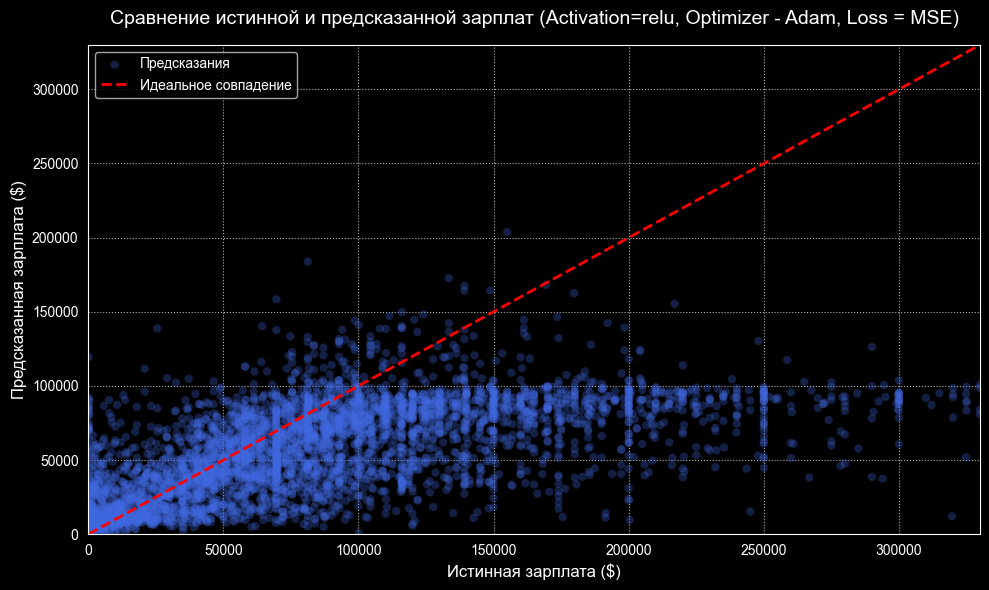

In [44]:
simple_salary_predictor_1 = SalaryPredictor(input_dim)
criterion_1 = choose_criterion()
optimizer_1 = choose_optimizer(model=simple_salary_predictor_1, optimizer_name='adam')
scheduler_1 = ReduceLROnPlateau(optimizer_1, mode='min', factor=0.5, patience=5)
model_1 = train_and_evaluate_regression(simple_salary_predictor_1,train_loader,test_loader,criterion_1, optimizer_1, scheduler=scheduler_1, epochs=EPOCHS,patience=PATIENCE,device='cpu',verbose=True)

plot_model_evaluation(model_1,'Activation=relu, Optimizer - Adam, Loss = MSE')


Epoch   1 | New best test loss: 2.306227
Test MAE ($): 59399.28 | RMSE ($): 81466.36 | R2 (Real): -0.3863
Epoch   2 | New best test loss: 1.614181
Test MAE ($): 50669.11 | RMSE ($): 72808.29 | R2 (Real): -0.1073
Epoch   3 | New best test loss: 1.506906
Test MAE ($): 48070.38 | RMSE ($): 69667.07 | R2 (Real): -0.0138
Epoch   4 | New best test loss: 1.227455
Test MAE ($): 43297.84 | RMSE ($): 64344.69 | R2 (Real): 0.1352
Epoch   5 | New best test loss: 1.135124
Test MAE ($): 39641.89 | RMSE ($): 59928.76 | R2 (Real): 0.2498
Epoch   6 | New best test loss: 1.102327
Test MAE ($): 40225.20 | RMSE ($): 60555.29 | R2 (Real): 0.2340
Test MAE ($): 41177.77 | RMSE ($): 62335.26 | R2 (Real): 0.1884
Epoch   8 | New best test loss: 1.070891
Test MAE ($): 39902.89 | RMSE ($): 60931.61 | R2 (Real): 0.2245
Epoch   9 | New best test loss: 1.050269
Test MAE ($): 38486.99 | RMSE ($): 58971.04 | R2 (Real): 0.2736
Epoch  10 | New best test loss: 1.043395
Test MAE ($): 38264.73 | RMSE ($): 58775.56 | R2 (Re

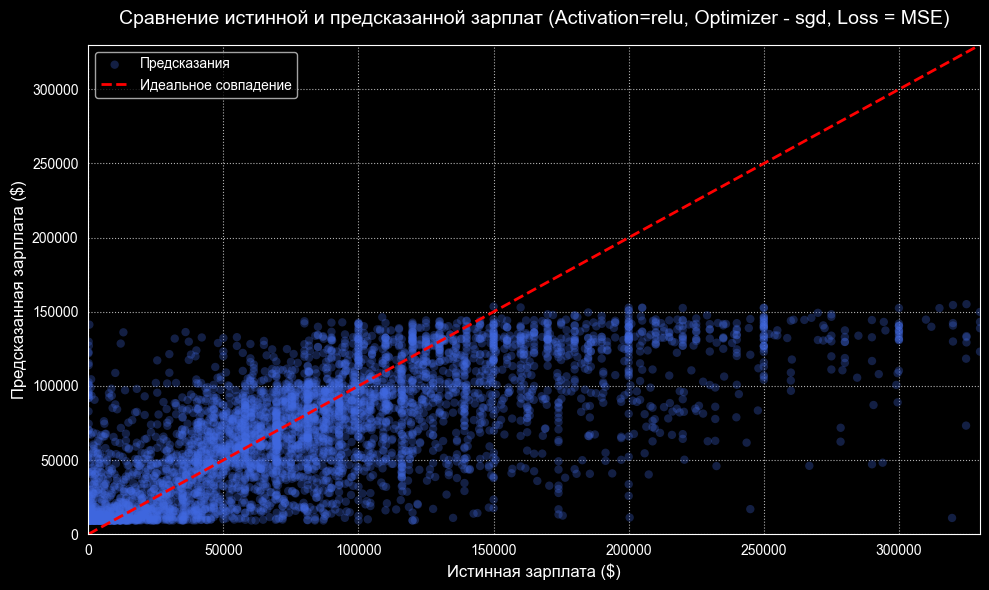

In [45]:
simple_salary_predictor_2 = SalaryPredictor(input_dim)
criterion_2 = choose_criterion()
optimizer_2 = choose_optimizer(model=simple_salary_predictor_2, optimizer_name='sgd')
scheduler_2 = ReduceLROnPlateau(optimizer_2, mode='min', factor=0.5, patience=PATIENCE)
model_2 = train_and_evaluate_regression(simple_salary_predictor_2,train_loader,test_loader,criterion_2, optimizer_2, scheduler=scheduler_2, epochs=EPOCHS,patience=PATIENCE,device='cpu',verbose=True)

plot_model_evaluation(model_2,'Activation=relu, Optimizer - sgd, Loss = MSE')


Epoch   1 | New best test loss: 74.590439
Test MAE ($): 89037.61 | RMSE ($): 112756.00 | R2 (Real): -1.6557
Epoch   2 | New best test loss: 20.718528
Test MAE ($): 88135.58 | RMSE ($): 111744.90 | R2 (Real): -1.6083
Epoch   3 | New best test loss: 2.674419
Test MAE ($): 68756.88 | RMSE ($): 91360.27 | R2 (Real): -0.7435
Epoch   4 | New best test loss: 1.385222
Test MAE ($): 46931.98 | RMSE ($): 67676.84 | R2 (Real): 0.0433
Epoch   5 | New best test loss: 1.274987
Test MAE ($): 42262.50 | RMSE ($): 62389.98 | R2 (Real): 0.1869
Epoch   6 | New best test loss: 1.186723
Test MAE ($): 47919.51 | RMSE ($): 70541.60 | R2 (Real): -0.0394
Epoch   7 | New best test loss: 1.107781
Test MAE ($): 41890.25 | RMSE ($): 61760.41 | R2 (Real): 0.2033
Test MAE ($): 46238.13 | RMSE ($): 69586.24 | R2 (Real): -0.0115
Epoch   9 | New best test loss: 1.090899
Test MAE ($): 42543.63 | RMSE ($): 63571.86 | R2 (Real): 0.1558
Test MAE ($): 41843.17 | RMSE ($): 62075.45 | R2 (Real): 0.1951
Test MAE ($): 43381.92 

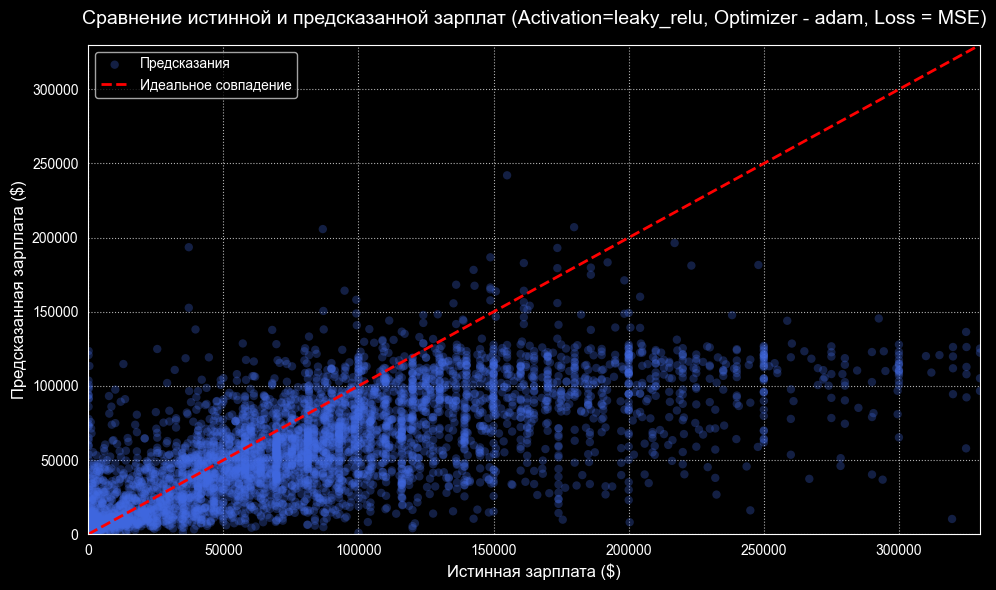

In [46]:
simple_salary_predictor_3 = SalaryPredictor(input_dim,activation='leaky_relu')
criterion_3 = choose_criterion()
optimizer_3 = choose_optimizer(model=simple_salary_predictor_3, optimizer_name='adam')
scheduler_3 = ReduceLROnPlateau(optimizer_3, mode='min', factor=0.5, patience=PATIENCE)
model_3 = train_and_evaluate_regression(simple_salary_predictor_3,train_loader,test_loader,criterion_3, optimizer_3, scheduler=scheduler_3, epochs=EPOCHS,patience=PATIENCE,device='cpu',verbose=True)

plot_model_evaluation(model_3,'Activation=leaky_relu, Optimizer - adam, Loss = MSE')


Epoch   1 | New best test loss: 55.509290
Test MAE ($): 89009.19 | RMSE ($): 112726.56 | R2 (Real): -1.6543
Epoch   2 | New best test loss: 16.224802
Test MAE ($): 87626.51 | RMSE ($): 111254.10 | R2 (Real): -1.5854
Epoch   3 | New best test loss: 5.379428
Test MAE ($): 78467.40 | RMSE ($): 100862.86 | R2 (Real): -1.1250
Epoch   4 | New best test loss: 3.103575
Test MAE ($): 71313.95 | RMSE ($): 93286.27 | R2 (Real): -0.8178
Epoch   5 | New best test loss: 2.250055
Test MAE ($): 63906.40 | RMSE ($): 85558.49 | R2 (Real): -0.5291
Epoch   6 | New best test loss: 2.070313
Test MAE ($): 58081.21 | RMSE ($): 78607.17 | R2 (Real): -0.2907
Test MAE ($): 59782.34 | RMSE ($): 81088.45 | R2 (Real): -0.3735
Epoch   8 | New best test loss: 1.912232
Test MAE ($): 55944.84 | RMSE ($): 76988.38 | R2 (Real): -0.2381
Test MAE ($): 55790.55 | RMSE ($): 77422.60 | R2 (Real): -0.2521
Epoch  10 | New best test loss: 1.689709
Test MAE ($): 50523.62 | RMSE ($): 71797.90 | R2 (Real): -0.0768
Epoch  11 | New b

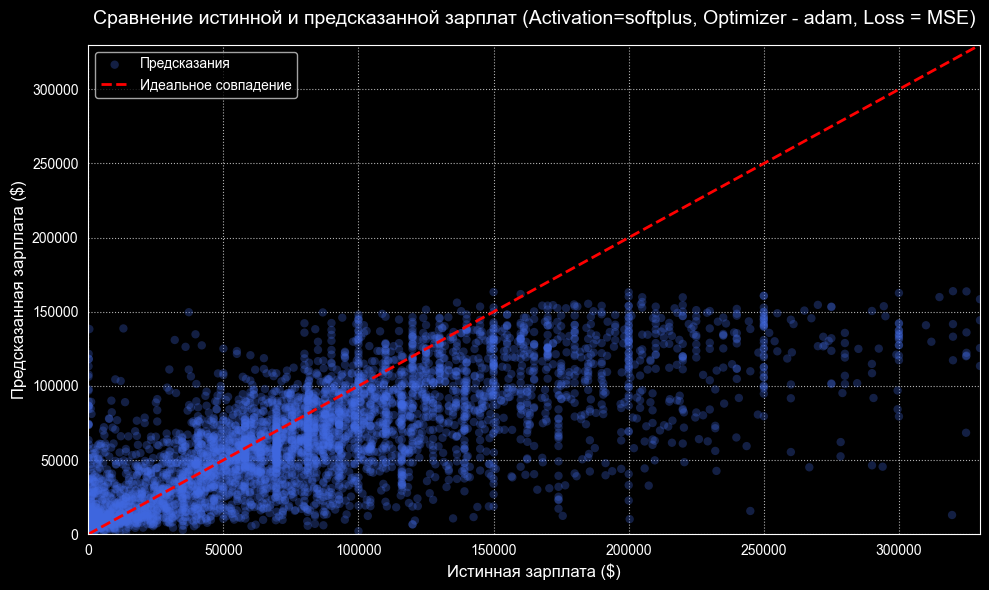

In [47]:
simple_salary_predictor_4 = SalaryPredictor(input_dim,activation='softplus')
criterion_4 = choose_criterion()
optimizer_4 = choose_optimizer(model=simple_salary_predictor_4, optimizer_name='adam')
scheduler_4 = ReduceLROnPlateau(optimizer_4, mode='min', factor=0.5, patience=PATIENCE)
model_4 = train_and_evaluate_regression(simple_salary_predictor_4,train_loader,test_loader,criterion_4, optimizer_4, scheduler=scheduler_4, epochs=EPOCHS,patience=PATIENCE,device='cpu',verbose=True)
plot_model_evaluation(model_4,'Activation=softplus, Optimizer - adam, Loss = MSE')


Epoch   1 | New best test loss: 8.126996
Test MAE ($): 89039.80 | RMSE ($): 112763.62 | R2 (Real): -1.6561
Epoch   2 | New best test loss: 2.673013
Test MAE ($): 85909.13 | RMSE ($): 109667.18 | R2 (Real): -1.5122
Epoch   3 | New best test loss: 0.470203
Test MAE ($): 49037.48 | RMSE ($): 71197.15 | R2 (Real): -0.0588
Epoch   4 | New best test loss: 0.414853
Test MAE ($): 46377.21 | RMSE ($): 68091.71 | R2 (Real): 0.0315
Epoch   5 | New best test loss: 0.400717
Test MAE ($): 45134.82 | RMSE ($): 67133.10 | R2 (Real): 0.0586
Epoch   6 | New best test loss: 0.396528
Test MAE ($): 45260.38 | RMSE ($): 67175.87 | R2 (Real): 0.0574
Epoch   7 | New best test loss: 0.393385
Test MAE ($): 45079.14 | RMSE ($): 67337.62 | R2 (Real): 0.0529
Epoch   8 | New best test loss: 0.385303
Test MAE ($): 43392.78 | RMSE ($): 65237.51 | R2 (Real): 0.1110
Epoch   9 | New best test loss: 0.368420
Test MAE ($): 43856.41 | RMSE ($): 65487.88 | R2 (Real): 0.1042
Epoch  10 | New best test loss: 0.352600
Test MAE 

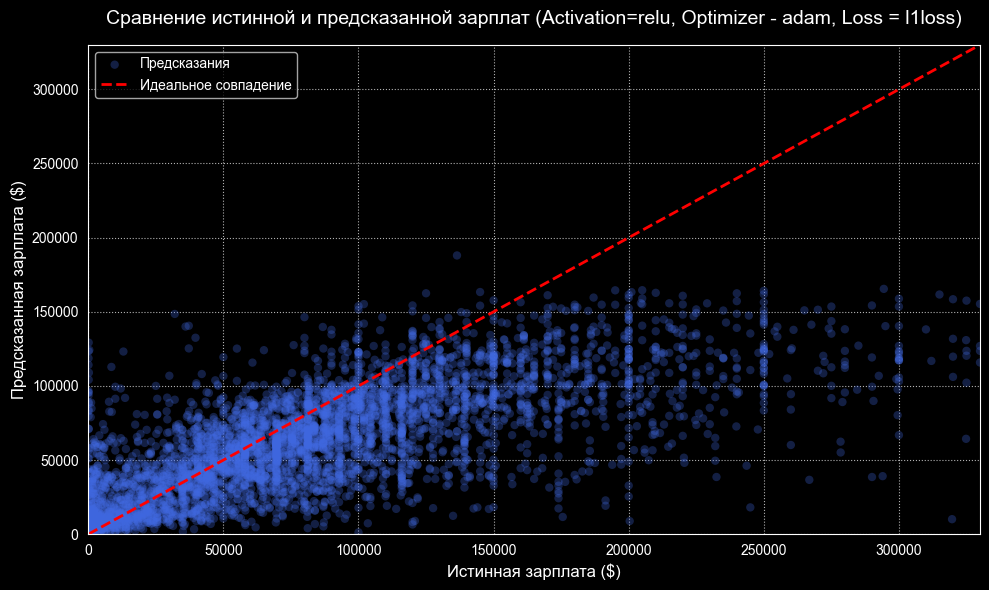

In [48]:
simple_salary_predictor_5 = SalaryPredictor(input_dim)
criterion_5 = choose_criterion('l1loss')
optimizer_5 = choose_optimizer(model=simple_salary_predictor_5, optimizer_name='adam')
scheduler_5 = ReduceLROnPlateau(optimizer_5, mode='min', factor=0.5, patience=PATIENCE)
model_5 = train_and_evaluate_regression(simple_salary_predictor_5,train_loader,test_loader,criterion_5, optimizer_5, scheduler=scheduler_5, epochs=EPOCHS,patience=PATIENCE,device='cpu',verbose=True)

plot_model_evaluation(model_5,'Activation=relu, Optimizer - adam, Loss = l1loss')


Epoch   1 | New best test loss: 7.855519
Test MAE ($): 89031.45 | RMSE ($): 112752.18 | R2 (Real): -1.6555
Epoch   2 | New best test loss: 2.991653
Test MAE ($): 83288.98 | RMSE ($): 106414.07 | R2 (Real): -1.3654
Epoch   3 | New best test loss: 0.487900
Test MAE ($): 46153.92 | RMSE ($): 66604.67 | R2 (Real): 0.0734
Epoch   4 | New best test loss: 0.384763
Test MAE ($): 39666.57 | RMSE ($): 58589.66 | R2 (Real): 0.2830
Epoch   5 | New best test loss: 0.370404
Test MAE ($): 39418.74 | RMSE ($): 58295.91 | R2 (Real): 0.2901
Epoch   6 | New best test loss: 0.363698
Test MAE ($): 38841.49 | RMSE ($): 58381.51 | R2 (Real): 0.2880
Epoch   7 | New best test loss: 0.357383
Test MAE ($): 39067.40 | RMSE ($): 58872.47 | R2 (Real): 0.2760
Epoch   8 | New best test loss: 0.330841
Test MAE ($): 37378.57 | RMSE ($): 56532.99 | R2 (Real): 0.3324
Test MAE ($): 38303.32 | RMSE ($): 57834.27 | R2 (Real): 0.3013
Test MAE ($): 36887.05 | RMSE ($): 55761.41 | R2 (Real): 0.3505
Epoch  11 | New best test lo

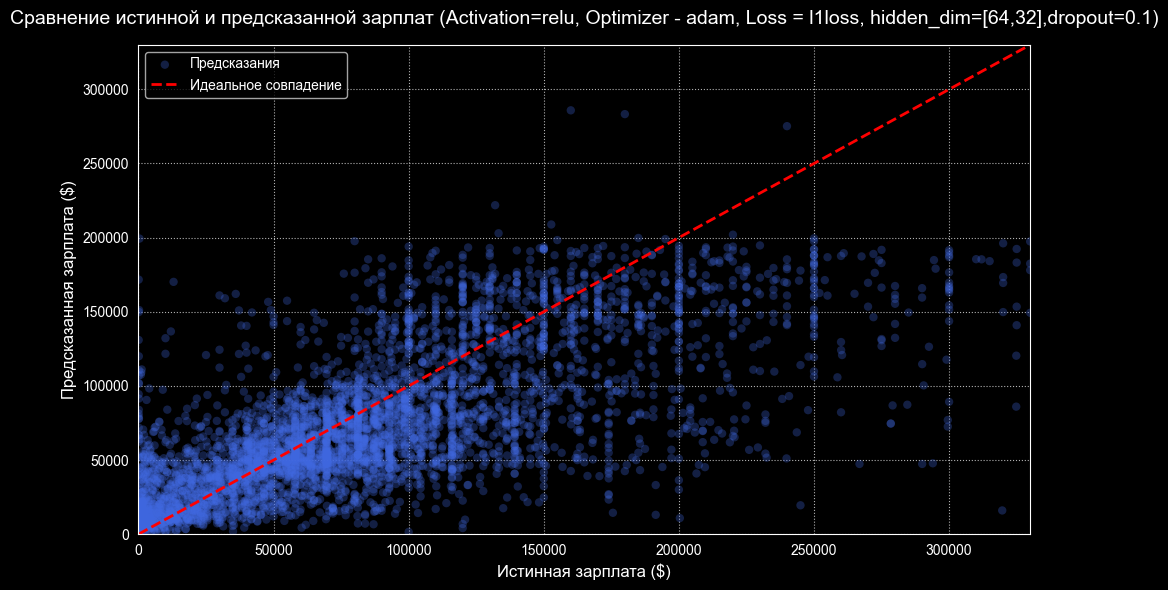

In [49]:
simple_salary_predictor_6 = SalaryPredictor(input_dim,hidden_dim=[64,32],dropout=0.1)
criterion_6 = choose_criterion('l1loss')
optimizer_6 = choose_optimizer(model=simple_salary_predictor_6, optimizer_name='adam')
scheduler_6 = ReduceLROnPlateau(optimizer_6, mode='min', factor=0.5, patience=PATIENCE)
model_6 = train_and_evaluate_regression(simple_salary_predictor_6,train_loader,test_loader,criterion_6, optimizer_6, scheduler=scheduler_6, epochs=EPOCHS,patience=PATIENCE,device='cpu',verbose=True)

plot_model_evaluation(model_6,'Activation=relu, Optimizer - adam, Loss = l1loss, hidden_dim=[64,32],dropout=0.1')

In [ ]:
simple_salary_predictor_7 = SalaryPredictor(input_dim,hidden_dim=[64,32],dropout=0.2)
criterion_7 = choose_criterion('l1loss')
optimizer_7 = choose_optimizer(model=simple_salary_predictor_7, optimizer_name='adam')
scheduler_7 = ReduceLROnPlateau(optimizer_7, mode='min', factor=0.5, patience=PATIENCE)
model_7 = train_and_evaluate_regression(simple_salary_predictor_7,train_loader,test_loader,criterion_7, optimizer_7, scheduler=scheduler_7, epochs=EPOCHS,patience=PATIENCE,device='cpu',verbose=True)

plot_model_evaluation(model_7,'Activation=relu, Optimizer - adam, Loss = l1loss, hidden_dim=[64,32],dropout=0.2')


Epoch   1 | New best test loss: 7.687961
Test MAE ($): 89033.82 | RMSE ($): 112758.80 | R2 (Real): -1.6558
Epoch   2 | New best test loss: 2.741103
Test MAE ($): 85416.14 | RMSE ($): 108955.75 | R2 (Real): -1.4797
Epoch   3 | New best test loss: 0.552717
Test MAE ($): 51505.86 | RMSE ($): 72865.53 | R2 (Real): -0.1090
Epoch   4 | New best test loss: 0.399950
Test MAE ($): 43097.45 | RMSE ($): 63659.06 | R2 (Real): 0.1535
Test MAE ($): 45856.51 | RMSE ($): 67402.99 | R2 (Real): 0.0510
Test MAE ($): 46829.24 | RMSE ($): 69186.04 | R2 (Real): 0.0001
Test MAE ($): 43663.89 | RMSE ($): 63765.11 | R2 (Real): 0.1507
Test MAE ($): 46656.34 | RMSE ($): 67282.36 | R2 (Real): 0.0544
Epoch   9 | New best test loss: 0.393522
Test MAE ($): 43827.86 | RMSE ($): 65172.92 | R2 (Real): 0.1128
Epoch  10 | New best test loss: 0.388995
Test MAE ($): 43661.71 | RMSE ($): 64719.61 | R2 (Real): 0.1251
Test MAE ($): 43901.33 | RMSE ($): 65231.31 | R2 (Real): 0.1112
Epoch  12 | New best test loss: 0.379401
Test

In [ ]:
simple_salary_predictor_8 = SalaryPredictor(input_dim,hidden_dim=[64,32],dropout=0.2)
criterion_8 = choose_criterion()
optimizer_8 = choose_optimizer(model=simple_salary_predictor_8, optimizer_name='adam')
scheduler_8 = ReduceLROnPlateau(optimizer_8, mode='min', factor=0.5, patience=PATIENCE)
model_8 = train_and_evaluate_regression(simple_salary_predictor_8,train_loader,test_loader,criterion_8, optimizer_8, scheduler=scheduler_8, epochs=EPOCHS,patience=PATIENCE,device='cpu',verbose=True)

plot_model_evaluation(model_8,'Activation=relu, Optimizer - adam, Loss = MSE, hidden_dim=[64,32],dropout=0.2')


In [ ]:
simple_salary_predictor_9 = SalaryPredictor(input_dim,hidden_dim=[64,32],dropout=0.2)
criterion_9 = choose_criterion('mae')
optimizer_9 = choose_optimizer(model=simple_salary_predictor_9, optimizer_name='adam')
scheduler_9 = ReduceLROnPlateau(optimizer_9, mode='min', factor=0.5, patience=PATIENCE)
model_9 = train_and_evaluate_regression(simple_salary_predictor_9,train_loader,test_loader,criterion_9, optimizer_9, scheduler=scheduler_9, epochs=EPOCHS,patience=PATIENCE,device='cpu',verbose=True)

plot_model_evaluation(model_9,'Activation=relu, Optimizer - adam, Loss = MAE, hidden_dim=[64,32],dropout=0.2')


In [ ]:
BATCH_SIZE = 32

In [ ]:
simple_salary_predictor_10 = SalaryPredictor(input_dim,hidden_dim=[128,64,32],dropout=0.1)
criterion_10 = choose_criterion('mae')
optimizer_10 = choose_optimizer(model=simple_salary_predictor_10, optimizer_name='adam')
scheduler_10 = ReduceLROnPlateau(optimizer_10, mode='min', factor=0.5, patience=PATIENCE)
model_10 = train_and_evaluate_regression(simple_salary_predictor_10,train_loader,test_loader,criterion_10, optimizer_10, scheduler=scheduler_10, epochs=EPOCHS,patience=PATIENCE,device='cpu',verbose=True)

plot_model_evaluation(model_10,'Activation=relu, Optimizer - adam, Loss = MAE, hidden_dim=[128,64,32],dropout=0.1')


In [ ]:
simple_salary_predictor_11 = SalaryPredictor(input_dim,hidden_dim=[128,64,32],dropout=0.1)
criterion_11 = choose_criterion('l1loss')
optimizer_11 = choose_optimizer(model=simple_salary_predictor_11, optimizer_name='adam')
scheduler_11 = ReduceLROnPlateau(optimizer_11, mode='min', factor=0.5, patience=PATIENCE)
model_11 = train_and_evaluate_regression(simple_salary_predictor_11,train_loader,test_loader,criterion_11, optimizer_11, scheduler=scheduler_11, epochs=EPOCHS,patience=PATIENCE,device='cpu',verbose=True)

plot_model_evaluation(model_11,'Activation=relu, Optimizer - adam, Loss = l1loss, hidden_dim=[128,64,32],dropout=0.1')

In [ ]:
simple_salary_predictor_12 = SalaryPredictor(input_dim,hidden_dim=[128,64,32],dropout=0.1)
criterion_12 = choose_criterion('mse')
optimizer_12 = choose_optimizer(model=simple_salary_predictor_12, optimizer_name='adam')
scheduler_12 = ReduceLROnPlateau(optimizer_12, mode='min', factor=0.5, patience=PATIENCE)
model_12 = train_and_evaluate_regression(simple_salary_predictor_12,train_loader,test_loader,criterion_12, optimizer_12, scheduler=scheduler_12, epochs=EPOCHS,patience=PATIENCE,device='cpu',verbose=True)

plot_model_evaluation(model_12,'Activation=relu, Optimizer - adam, Loss = MSE, hidden_dim=[128,64,32],dropout=0.1')
